Name: Pradnya Pawar

Roll No: 5010

Div: A

Subject: Intro to DataScience

Course: SYBBA

**Importing & Loading Data**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/Investor Sentiment and Stock Market Behavior in India  (Responses) - Form Responses 1.csv")

# Rename columns for easy use
df = df.rename(columns={
    'Q1] what is your Age?': 'Age',
    'Q2]  what is your Gender?': 'Gender',
    'Q3]  What is your highest completed education level? ': 'Education',
    '4]  Which of the following best describes your current occupation? ': 'Occupation',
    '5]  On average, how much do you invest in stocks per month? ': 'Monthly Investment',
    '  6]  Which type of investment do you prefer the most?  ': 'Investment Type',
    '  7]  Which sector do you prefer for your investments?  ': 'Sector',
    '  8]  How frequently do you trade or invest in stocks?  ': 'Frequency',
    '  9]  What is your level of risk tolerance when it comes to investments?  ': 'Risk',
    '  10]  What has the biggest influence on your investment decisions?  ': 'Influence'
})


**A. DATA CLEANING & PREPARATION**

1. Identify and handle missing values in the “monthly investment amount” column.

In [ ]:
print(df['Monthly Investment'].isnull().sum())

# Fill missing with average
df['Monthly Investment'].fillna(df['Monthly Investment'].mode()[0], inplace=True)


2


/tmp/ipython-input-1133207903.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Monthly Investment'].fillna(df['Monthly Investment'].mode()[0], inplace=True)


2. Convert the investment amount (₹) column into a numeric format and remove currency symbols

In [ ]:
df['Monthly Investment'] = df['Monthly Investment'].astype(str)
df['Monthly Investment'] = df['Monthly Investment'].str.replace('₹','')
df['Monthly Investment'] = df['Monthly Investment'].str.replace(',','')
df['Monthly Investment'] = pd.to_numeric(df['Monthly Investment'], errors='coerce')
print(df['Monthly Investment'].head())


0     1000
1     1000
2    20000
3     5000
4     1000
Name: Monthly Investment, dtype: int64


3. Standardize inconsistent values in Gender and Education Level columns.


In [ ]:
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Gender'] = df['Gender'].replace({
    'male':'Male',
    'female':'Female'
})

df['Education'] = df['Education'].str.strip().str.title()
print(df['Gender'].unique())


['Female' 'Male' 'other']


4. Create a new column Age Group (e.g., Below 20, 20–40, Above 40).

In [ ]:
def age_group(age):
    if age < 20:
        return "Below 20"
    elif age <= 40:
        return "20-40"
    else:
        return "Above 40"

df['Age Group'] = df['Age'].apply(age_group)
print(df[['Age','Age Group']].head())


   Age Age Group
0   19  Below 20
1   19  Below 20
2    2  Below 20
3   19  Below 20
4   18  Below 20


5. Check and remove any outliers in monthly investment amounts.

In [ ]:
print("Before removing outliers:", len(df))

Q1 = df['Monthly Investment'].quantile(0.25)
Q3 = df['Monthly Investment'].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

df = df[(df['Monthly Investment'] >= Q1 - 1.5*IQR) &
        (df['Monthly Investment'] <= Q3 + 1.5*IQR)]

print("After removing outliers:", len(df))


Before removing outliers: 103
Q1 = 1000.0
Q3 = 10000.0
IQR = 9000.0
After removing outliers: 103


**📊 B. DESCRIPTIVE DATA ANALYSIS**

6. Calculate the average monthly investment by all respondents.

In [ ]:
print(df['Monthly Investment'].mean())


5631.0679611650485


7. Find the most preferred investment type among respondents.

In [ ]:
print(df['Investment Type'].mode()[0])


Stocks


8. Determine the sector with the highest number of investors.


In [ ]:
print(df['Sector'].value_counts().idxmax())


IT


9. Calculate the distribution of risk tolerance levels.

In [ ]:
print(df['Risk'].value_counts())


Risk
Medium    46
High      31
Low       25
Name: count, dtype: int64


10. Find the average investment amount by occupation.

In [ ]:
print(df.groupby('Occupation')['Monthly Investment'].mean())


Occupation
Employed          6636.363636
Retired          11375.000000
Self-Employed     9823.529412
Student           1694.444444
Unemployed        4666.666667
Name: Monthly Investment, dtype: float64


**C. GROUPING & AGGREGATION**

11. Group data by Gender and compute the average monthly investment.

In [ ]:
print(df.groupby('Gender')['Monthly Investment'].mean())


Gender
Female    5238.095238
Male      5703.703704
other     7428.571429
Name: Monthly Investment, dtype: float64


12. Group respondents by Education Level and count the number of investors in each group.

In [ ]:
print(df['Education'].value_counts())


Education
Undergraduate    57
Postgraduate     23
High School      15
Doctorate         8
Name: count, dtype: int64


13. Group by Investment Type and calculate the average risk tolerance.

In [ ]:
print(df.groupby('Investment Type')['Risk'].count())


Investment Type
Bonds            9
Crypto          19
ETFs             8
Mutual Funds    26
Stocks          39
Name: Risk, dtype: int64


14. Group by Age Group and determine the most preferred investment type.

In [ ]:
print(df.groupby('Age Group')['Investment Type']
      .agg(lambda x: x.value_counts().idxmax()))


Age Group
20-40       Stocks
Above 40    Stocks
Below 20    Stocks
Name: Investment Type, dtype: object


15. Group by Sector Preference and calculate the total investment amount.

In [ ]:
print(df.groupby('Sector')['Monthly Investment'].sum())


Sector
Automobile     45000
Banking       128000
FMCG           78000
IT            161000
Pharma        167000
Name: Monthly Investment, dtype: int64


**D. Data Visualization (Matplotlib)**

16. Create a bar chart showing the number of respondents by Investment Type.

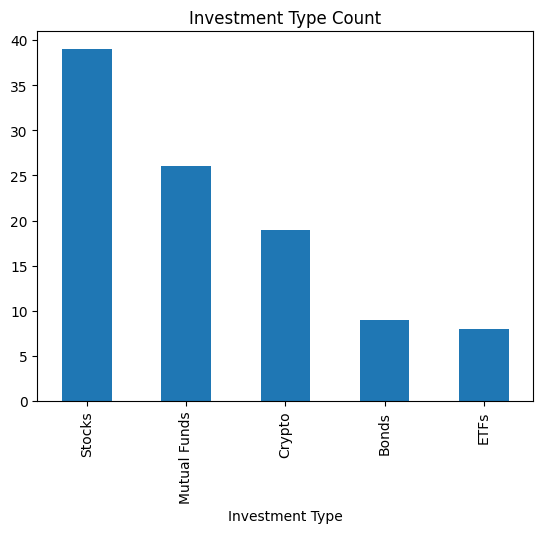

In [ ]:
df['Investment Type'].value_counts().plot(kind='bar')
plt.title("Investment Type Count")
plt.show()


17. Plot a pie chart representing the distribution of Risk Tolerance levels.


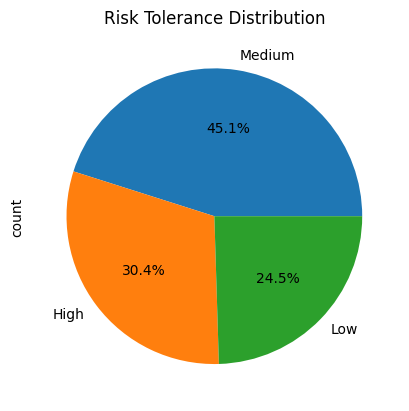

In [ ]:
df['Risk'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Tolerance Distribution")
plt.show()


18. Draw a bar graph showing average monthly investment by Gender.


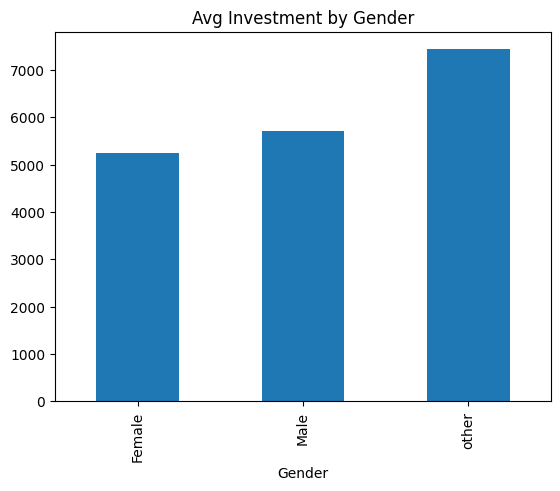

In [ ]:
df.groupby('Gender')['Monthly Investment'].mean().plot(kind='bar')
plt.title("Avg Investment by Gender")
plt.show()


19. Create a histogram to show the distribution of Age of respondents.


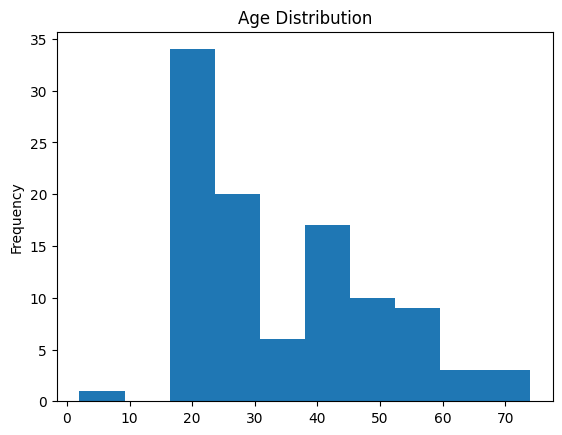

In [ ]:
df['Age'].plot(kind='hist')
plt.title("Age Distribution")
plt.show()


20. Plot a bar chart showing the count of investors by Sector Preference.


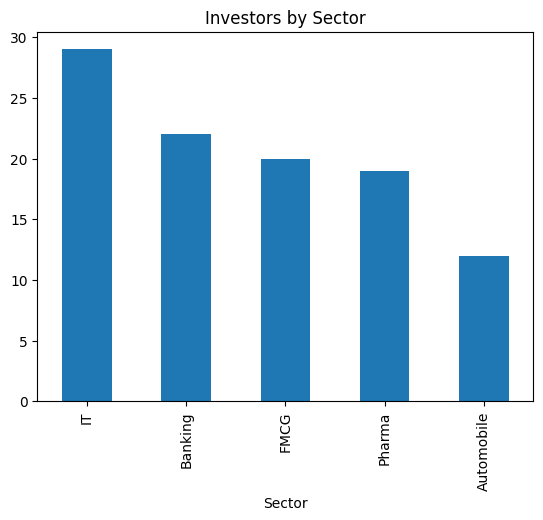

In [ ]:
df['Sector'].value_counts().plot(kind='bar')
plt.title("Investors by Sector")
plt.show()


**E. Combined Analysis + Visualization**

21. Create a bar chart showing average investment amount by Age Group.


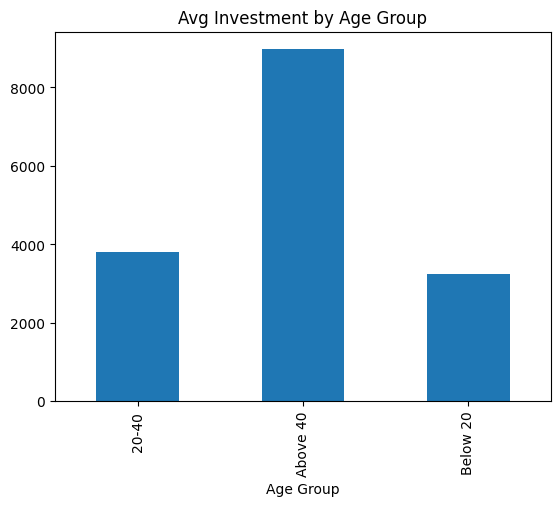

In [ ]:
df.groupby('Age Group')['Monthly Investment'].mean().plot(kind='bar')
plt.title("Avg Investment by Age Group")
plt.show()


22. Visualize the relationship between Occupation and Investment Frequency using a bar chart.


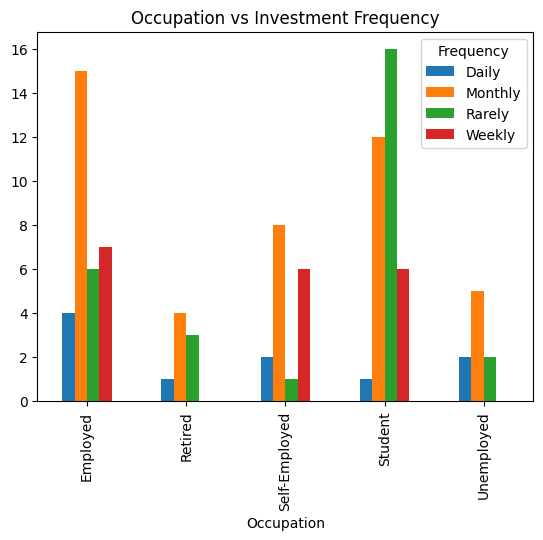

In [ ]:
pd.crosstab(df['Occupation'], df['Frequency']).plot(kind='bar')
plt.title("Occupation vs Investment Frequency")
plt.show()


23. Plot a stacked bar chart showing Investment Type vs Risk Tolerance.


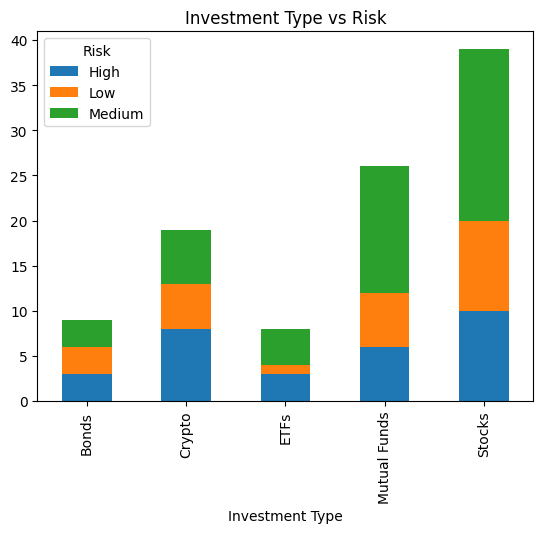

In [ ]:
pd.crosstab(df['Investment Type'], df['Risk']).plot(kind='bar', stacked=True)
plt.title("Investment Type vs Risk")
plt.show()


24. Create a bar graph showing how investment influence sources vary across genders.


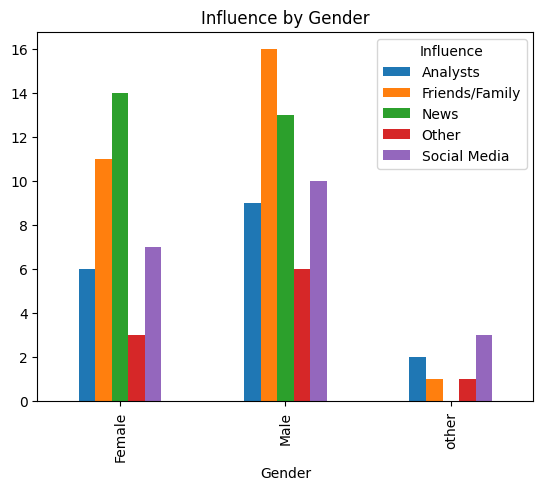

In [ ]:
pd.crosstab(df['Gender'], df['Influence']).plot(kind='bar')
plt.title("Influence by Gender")
plt.show()


25. Identify the top 3 sectors by total investment and visualize them using a bar chart.


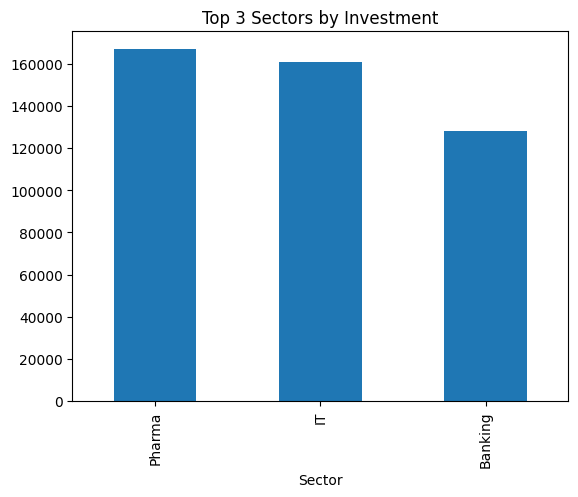

In [ ]:
top3 = df.groupby('Sector')['Monthly Investment'].sum().sort_values(ascending=False).head(3)
top3.plot(kind='bar')
plt.title("Top 3 Sectors by Investment")
plt.show()
